# Obtain graph 

## Summary

This notebook shows how to generate graphs based on the representations that provide the best models, to compare what are the different features between each system. 

In [2]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import radius_graph
import networkx as nx
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import tqdm
import json

/home/bcz/miniconda3/envs/pyg/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/bcz/miniconda3/envs/pyg/lib/python3.11/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/bcz/miniconda3/envs/pyg/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/bcz/miniconda3/envs/pyg/lib/python3.11/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at4_ops16div__Tensor_mode4callERNS_6TensorERKS2_St8optionalIN3c1017basic_string_viewIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/bcz/miniconda3/envs/pyg/lib/python3.11/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'.

## Defining molecular dynamics trajectories and selection

First, we need to define the selection that we will be applying. Below an example.

In [3]:
selection = "name CA"
radius = 4.5

Now, we define manually all the files that we are going to be using in the analysis. 

In [4]:
data_files = [
    {
        "label": [0], 
        "topology_filename": "../data/md-2025-06-09/FP7ns.prmtop", 
        "coordinates_filename": "../data/md-2025-06-09/FP7_R0_TRAJ_150ns.nc"
    }, {
        "label": [1], 
        "topology_filename": "../data/md-2025-06-09/FP11ns.prmtop", 
        "coordinates_filename": "../data/md-2025-06-09/FP11_R0_TRAJ_150ns.nc"
    }
]

In [5]:
with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

## Loading data

We try to approach as much as possible the process that was used in the training. 

In [6]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

In [7]:
_all_labels = [item['label'][0] for item in data_files]
trajectories_by_labels = [[] for _ in _all_labels]
for file in data_files:
    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    trajectories_by_labels[file['label'][0]] += list(trajectory_to_data(u, selection, residue_index, atom_type_index, file['label']))

In [8]:
trajectory_loaders = [
    DataLoader(trj, batch_size=1) for trj in trajectories_by_labels
]
trajectory_loaders

## Calculations

**Note**: this part could become more efficient if using sparse matrices...

In [10]:
Gs = []

for t in trajectory_loaders:
    G = nx.Graph()
    example = list(t)[0]
    G.add_nodes_from([(i, dict(residue=res.item(), type=type.item())) for i, (res, type) in enumerate(zip(example.res, example.types))])
    adjacency_matrix = torch.zeros([len(example.pos), len(example.pos)])# .to_sparse()
    for d in tqdm.tqdm(t):
        edge_index = radius_graph(d.pos, r=radius, batch=d.batch)
        adjacency_matrix[edge_index[0], edge_index[1]] += 1
    
    edge_list = torch.argwhere(adjacency_matrix != 0)
    edges_with_weights = [(i, j, adjacency_matrix[i, j].item()) for i, j in edge_list.tolist()]
    G.add_weighted_edges_from(edges_with_weights)
    Gs.append(G)

100%|██████████| 1500/1500 [00:03<00:00, 478.31it/s]


In [33]:

nx.write_graphml(Gs[0], "test.0.graphml")
nx.write_graphml(Gs[1], "test.1.graphml")

In [34]:
G0, G1 = Gs

## Averaging graph information

the following blocks of code convert the edge and node information to datframes to enable visualization.

In [35]:
def edges_to_df(g: nx.Graph):
    """
    Edges to df creates a dataframe from the edges that includes its weights
    
    :param g: network as nx.Graph
    """
    df = []
    for e1, e2, data in g.edges(data=True):
        df.append({'e1': e1, 'e2': e2, 'w': data['weight']})
    return pd.DataFrame.from_records(df)

def nodes_to_df(g: nx.Graph):
    """
    Nodes to df creates a dataframe from the nodes that includes all their embedded information

    :param g: network as nx.Graph
    """
    df = []
    for n, data in g.nodes(data=True):
        df.append(dict(n=n, **data))
    return pd.DataFrame.from_records(df)

Now, we create dataframes that contain the information of both end nodes of each edge in each row of the dataframe.

In [36]:
G0_edges_df = edges_to_df(G0)
G1_edges_df = edges_to_df(G1)
G0_nodes_df = nodes_to_df(G0)
G1_nodes_df = nodes_to_df(G1)
G_nodes_df = pd.concat([G0_nodes_df, G1_nodes_df]).drop_duplicates('n', keep='first')
with open("residue-list.json") as f:
    residue_index = dict((value, key) for key, value in json.load(f).items())
G_nodes_df['residue'] = G_nodes_df['residue'].map(residue_index)

# G0_edges_df = pd.merge(G0_edges_df, G0_nodes_df, left_on='e1', right_on='n')
# G0_edges_df = pd.merge(G0_edges_df, G0_nodes_df, left_on='e2', right_on='n', suffixes=['_e1', '_e2'])
# G1_edges_df = pd.merge(G1_edges_df, G1_nodes_df, left_on='e1', right_on='n')
# G1_edges_df = pd.merge(G1_edges_df, G1_nodes_df, left_on='e2', right_on='n', suffixes=['_e1', '_e2'])

In [37]:
G0_edges_df

,e1,e2,w
0,0,1,1500.0
1,1,2,1500.0
2,1,28,32.0
3,2,3,1500.0
4,3,4,1500.0
...,...,...,...
1243,742,743,1500.0
1244,743,744,1500.0
1245,744,745,1500.0
1246,745,746,1500.0


Finally we compute the difference between edge values.

In [38]:
G_diff = pd.merge(G0_edges_df[['e1', 'e2', 'w']], G1_edges_df[['e1', 'e2', 'w']], on=['e1', 'e2'], how='outer').fillna(0)
G_diff = pd.merge(G_diff, G_nodes_df, left_on='e1', right_on='n')
G_diff = pd.merge(G_diff, G_nodes_df, left_on='e2', right_on='n', suffixes=['_e1', '_e2'])

G_diff['w_diff'] = np.abs(G_diff['w_y'] - G_diff['w_x'])

In [39]:

G_diff

,e1,e2,w_x,w_y,n_e1,residue_e1,type_e1,n_e2,residue_e2,type_e2,w_diff
0,0,1,1500.0,1500.0,0,GLU,13,1,SER,13,0.0
1,0,3,0.0,1.0,0,GLU,13,3,GLU,13,1.0
2,0,4,0.0,2.0,0,GLU,13,4,PRO,13,2.0
3,0,25,0.0,17.0,0,GLU,13,25,PRO,13,17.0
4,1,2,1500.0,1500.0,1,SER,13,2,TRP,13,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1394,742,743,1500.0,1500.0,742,HIE,13,743,GLN,13,0.0
1395,743,744,1500.0,1500.0,743,GLN,13,744,PRO,13,0.0
1396,744,745,1500.0,1500.0,744,PRO,13,745,ASN,13,0.0
1397,745,746,1500.0,0.0,745,ASN,13,746,SER,13,1500.0


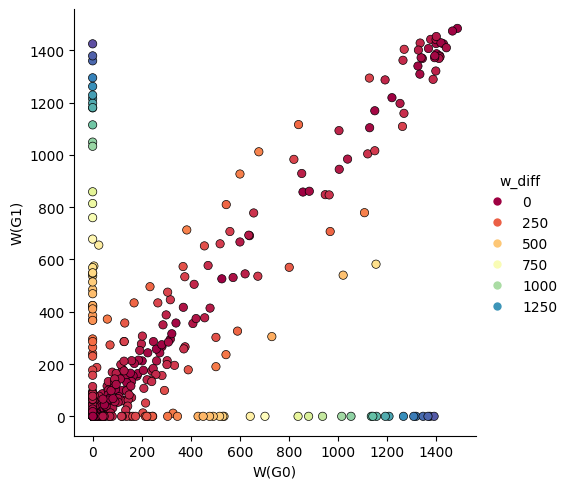

In [40]:
g = sns.relplot(G_diff.query('w_x != 1500 and w_y != 1500'), x='w_x', y='w_y', hue='w_diff', palette='Spectral', edgecolor='black')
g.set_xlabels("W(G0)")
g.set_ylabels("W(G1)")

### Node averaged graph

Now we take the previous ´df´ and we group all nodes and add their number of contacts

In [41]:
G_node_weigths_df = pd.concat(
    [
        G_diff[['e1', 'w_x', 'w_y', 'residue_e1']].rename(columns={'e1': 'n', 'residue_e1': 'residue'}),
        G_diff[['e2', 'w_x', 'w_y', 'residue_e2']].rename(columns={'e2': 'n', 'residue_e2': 'residue'}),
    ]
).groupby(['n', 'residue'], as_index=False).sum()
G_node_weigths_df

,n,residue,w_x,w_y
0,0,GLU,1500.0,1520.0
1,1,SER,3032.0,3001.0
2,2,TRP,3000.0,3003.0
3,3,GLU,3006.0,3001.0
4,4,PRO,3000.0,3003.0
...,...,...,...,...
743,743,GLN,3554.0,3002.0
744,744,PRO,3051.0,3003.0
745,745,ASN,3007.0,1520.0
746,746,SER,3020.0,0.0


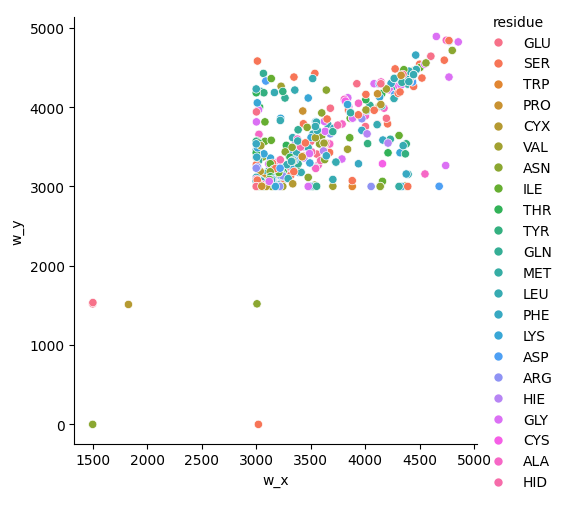

In [42]:
sns.relplot(G_node_weigths_df, x='w_x', y='w_y', hue='residue')



- Most residues have at least an interaction with their immediate neighbors, which is why this plot has two lines at x=3000 and y=3000. There are only a few exceptions to this rule, which might be worth checking.
- There are many interactions between nodes that are simulation specific, and then there are points in the diagonal that display more nuanced differences. My bet is that the difference is in the edges that are system dependent, not on the ones whose changes are simulation dependent.